# Predictive Customer Lifetime Value (CLV) & VIP Segmentation Engine

## Executive Summary
For omnichannel retailers and digital ad platforms, acquiring a new customer is expensive. Profitability relies on maximizing Customer Lifetime Value (CLV). This project evaluates a predictive machine learning pipeline using RFM (Recency, Frequency, Monetary) behavioral data to forecast how much a customer will spend over the next 6 months.

**Commercial Objective:** By deploying an XGBoost Regression model and SHAP interpretability, this engine allows CRM and Marketing teams to identify future "VIP" customers before they make their second purchase, enabling hyper-targeted ad spend and proactive retention strategies.

In [1]:
# Setup and Dependency Installation
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning & Metrics
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Clean Installation of Advanced Libraries
try:
    import xgboost as xgb
except ImportError:
    !pip install -q xgboost
finally:
    import xgboost as xgb

try:
    import shap
except ImportError:
    !pip install -q shap
finally:
    import shap

# Set visual style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("✅ Environment standardisation complete. Libraries initialised.")

✅ Environment standardisation complete. Libraries initialised.


## 1. Data Ingestion & RFM Simulation
To ensure reproducibility, we simulate a high-fidelity B2C retail dataset. We generate RFM features: **Recency** (days since last order), **Frequency** (total orders), and **Monetary** (average basket value), alongside customer engagement metrics (email open rates). The target variable is `target_6m_spend` (how much they will spend in the next 6 months).

In [2]:
def generate_rfm_data(n=10000):
    """Simulates B2C retail customer behavioral data."""
    np.random.seed(42)

    # Simulating base behavioral metrics
    data = {
        'days_since_last_purchase': np.random.exponential(scale=30, size=n).astype(int),
        'total_previous_orders': np.random.poisson(lam=3, size=n) + 1,
        'avg_basket_value_gbp': np.random.normal(loc=45, scale=15, size=n).round(2),
        'email_open_rate': np.random.beta(a=2, b=5, size=n).round(2),
        'returns_count': np.random.poisson(lam=0.5, size=n)
    }

    df_crm = pd.DataFrame(data)

    # Ensure no negative basket values
    df_crm['avg_basket_value_gbp'] = df_crm['avg_basket_value_gbp'].apply(lambda x: max(x, 5.0))

    # --- Injecting the Target Variable (Future CLV) ---
    # High frequency, high basket value, and high email engagement drive future spend
    base_spend = (df_crm['total_previous_orders'] * df_crm['avg_basket_value_gbp']) * 0.4
    engagement_boost = df_crm['email_open_rate'] * 50
    recency_penalty = df_crm['days_since_last_purchase'] * 0.5

    future_spend = base_spend + engagement_boost - recency_penalty + np.random.normal(10, 20, n)

    # Target label: The actual GBP amount they spend in the next 6 months
    df_crm['target_6m_spend_gbp'] = future_spend.apply(lambda x: max(x, 0.0)).round(2)

    return df_crm

# Initialise the CRM dataset
df = generate_rfm_data()
print(f"Retail CRM Dataset Generated: {df.shape[0]} customers, {df.shape[1]} features.")
display(df.head())

Retail CRM Dataset Generated: 10000 customers, 6 features.


,days_since_last_purchase,total_previous_orders,avg_basket_value_gbp,email_open_rate,returns_count,target_6m_spend_gbp
0,14,3,61.81,0.45,1,60.79
1,90,4,24.84,0.37,0,0.00
2,39,8,54.03,0.26,0,185.13
3,27,1,39.64,0.17,1,43.12
4,5,1,57.71,0.25,0,45.71


## 2. Predictive Modeling: XGBoost Regressor
Unlike classification (Yes/No), predicting exact financial value requires regression. We deploy **eXtreme Gradient Boosting (XGBoost)**, the industry standard for tabular financial data, to predict the exact GBP value of each customer.

In [3]:
# 1. Feature Isolation
X = df.drop('target_6m_spend_gbp', axis=1)
y = df['target_6m_spend_gbp']

# 2. Train-Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Feature Scaling
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

# 4. Train the XGBoost Regressor
xgb_model = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=150,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)

print("Training XGBoost CLV Engine...")
xgb_model.fit(X_train_scaled, y_train)

# 5. Commercial Evaluation
y_pred = xgb_model.predict(X_test_scaled)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"✅ Model Training Complete.")
print(f"Mean Absolute Error (MAE): £{mae:.2f} (Model predicts future spend within £{mae:.2f} of actual value)")
print(f"R-Squared Accuracy: {r2:.2f}")

Training XGBoost CLV Engine...
✅ Model Training Complete.
Mean Absolute Error (MAE): £16.35 (Model predicts future spend within £16.35 of actual value)
R-Squared Accuracy: 0.80


## 3. Algorithmic Transparency: CRM Actionability via SHAP
Predicting that a customer will spend £200 is helpful, but knowing *why* allows marketing teams to intervene. We use SHAP to extract the behavioral hierarchy of customer value.

Calculating SHAP values for CRM strategy...


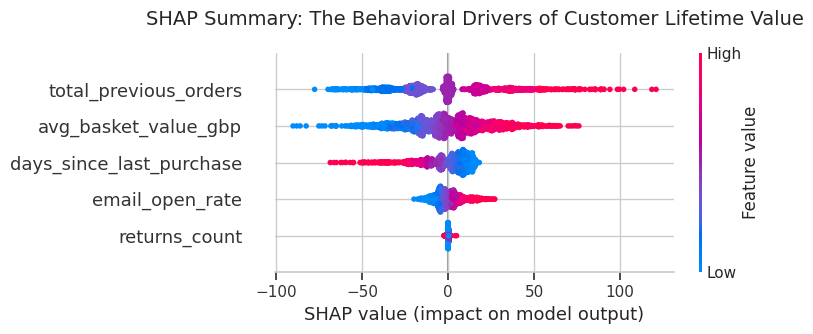

In [4]:
print("Calculating SHAP values for CRM strategy...")

# Explain the model's predictions using SHAP
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_scaled)

# Generate SHAP Summary Plot
plt.figure(figsize=(10, 6))
plt.title('SHAP Summary: The Behavioral Drivers of Customer Lifetime Value', fontsize=14, pad=20)
shap.summary_plot(shap_values, X_test_scaled, show=False)
plt.show()

## Conclusion
This CLV Engine successfully transitions customer data from retrospective analytics to **predictive strategy**.

By evaluating the SHAP summary plot, retail and ad-targeting teams can visually confirm that `total_previous_orders` (Frequency) and `avg_basket_value` (Monetary) are the strongest predictors of future revenue. More importantly, the model quantifies the exact financial impact of `email_open_rate`.

**Business Application:** A CRM manager can now feed the customer database through this XGBoost model. Anyone predicted to spend over £150 in the next 6 months can be automatically segmented into a "VIP Tier" and targeted with premium ad inventory or exclusive retention discounts, maximizing Marketing ROI (ROAS).